In [10]:
import sys
import math
import torch
import random
import numpy as np 
import libpyDirtMP as prx
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

def state_increment(space_point, step_inc, lower_bounds, upper_bounds):
    for i in range(len(space_point)):
        pt[i] = pt[i] + step_inc
        if pt[i] <= upper_bounds[i]:
            return True
        pt[i] = lower_bounds[i]
    return False;


In [11]:

params = prx.param_loader("examples/tripods/ackermann_ha_roa.yaml", sys.argv);

simulation_step = params["simulation_step"].as_float()
prx.set_simulation_step(simulation_step)
prx.init_random(params["random_seed"].as_int())

obstacles = prx.load_obstacles(params["environment"].as_string())
obstacle_list = obstacles.objects
obstacle_names = obstacles.names

plant_name = params["/plant/name"].as_string();
plant_path = params["/plant/path"].as_string();
plant = prx.system_factory.create_system(plant_name, plant_path);
if plant == None: 
    print("Error: plant not found!")
    exit(-1)

wm = prx.world_model([plant], obstacle_list)
wm.create_context("context", [plant_name], obstacle_names)
context = wm.get_context("context")

ss = context.system_group.get_state_space();
cs = context.system_group.get_control_space();

lower_bounds = params["/plant/state_space_lower_bound"].as_float_vector()
upper_bounds = params["/plant/state_space_upper_bound"].as_float_vector()
ss.set_bounds(lower_bounds, upper_bounds);

cs_lb = params["/plant/control_space_lower_bound"].as_float_vector()
cs_up = params["/plant/control_space_upper_bound"].as_float_vector()
# cs_lb[1] = -30
# cs_up[1] = 0
cs.set_bounds(cs_lb, cs_up);

start_state = ss.make_point();
goal_state = ss.make_point();
end_state   = ss.make_point()

ss.copy_point_from_vector(start_state, params["/plant/start_state"].as_float_vector())
ss.copy_point_from_vector(goal_state, params["/plant/goal_state"].as_float_vector())
ss.copy_from_point(start_state)
    
checker = prx.condition_check(params["checker_type"].as_string(), params["checker_value"].as_int());

ss_dim = ss.get_dimension();
cs_dim = cs.get_dimension();

ss.print_bounds();
cs.print_bounds();

ctrl_1 = prx.ackermann_FO_ctrl(plant, "ackermann_FO_ctrl_1");
ctrl_2 = prx.ackermann_FO_ctrl(plant, "ackermann_FO_ctrl_2");





def compute_trajectory(start_state_v, end_state_v):
    solution_traj = prx.trajectory(ss);
    ss.copy_from_vector(start_state_v)
    ss.copy_point_from_vector(goal_state, end_state_v)
    checker.reset()
    ctrl_1.set_goal(goal_state)
    solution_traj.copy_onto_back(ss);
    k_rho_1   = +1.0
    k_alpha_1 = +5.0
    k_beta_1  = -2.750

    ctrl_1.set_gains(k_rho_1, k_alpha_1, k_beta_1)
    while True:
        ctrl_1.compute_controls();
        cs.enforce_bounds();

        plant.propagate(simulation_step);
#         ss.copy_to_point(end_state);

        # Remove this line when doing intensive computation
        solution_traj.copy_onto_back(ss);

        if checker.check() or prx.space_t.euclidean_2d(solution_traj.back(), end_state, 0, 3) <= 0.1:
            break
    return solution_traj

def compute_trajectories(start_states, goal, f_trajs = compute_trajectory):
    trajs = []
    for start in start_states:
#         print("start:", start)
        trajs.append(f_trajs(start, goal))
    return trajs
        

[PRX WARN] void prx::param_loader::add_opts(std::vector<std::string>):166 param_loader - Error reading param: -f
[PRX WARN] void prx::param_loader::add_opts(std::vector<std::string>):166 param_loader - Error reading param: /Users/Gary/Library/Jupyter/runtime/kernel-3e0b9958-6db1-4315-9165-2bf3175b8aed.json


Bounds: ( -100, -100, -3.14159 ), (100, 100, 3.14159)
Bounds: ( -1.05, 0 ), (1.05, 30)


In [12]:
traj_1 = compute_trajectory([-4, 0, 0], [0, 0, np.pi/2])

In [13]:
def plot_trajs(trajs):
    fig = plt.figure(figsize=(8, 3), dpi=150, frameon=False)
    plot_limits = np.column_stack(([-10, -10], [10, 10]))

    ax = plt.subplot(121)
    
    for traj in trajs:
        xs = []
        ys = []
#     print(len(traj_1))
        for state in traj:
            xs.append(state[0])
            ys.append(state[1])

        ax.plot(xs, ys, '-', linewidth=1)
#         print("( {:.2f} {:.2f} )".format(xs[0], ys[0]))
        plt.arrow(xs[0], ys[0], 0.1*np.cos(traj[0][2]), 0.1*np.sin(traj[0][2]), shape='full', lw=0, length_includes_head=True, head_width=.5, color="red")
        plt.arrow(xs[-2], ys[-2], 0.1*np.cos(traj[len(traj)-1][2]), 0.1*np.sin(traj[len(traj)-1][2]), shape='full', lw=0, length_includes_head=False, head_width=.5, color="green")
    ax.set_xlim(plot_limits[0])
    ax.set_ylim(plot_limits[1])



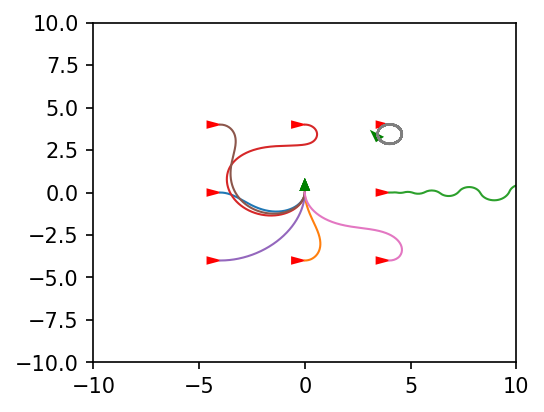

In [14]:
s_points = [ [-4, 0, 0], [0, -4, 0], [4, 0, 0], [0, 4, 0], [-4, -4, 0], [-4, 4, 0], [4, -4, 0], [4, 4, 0] ]
trajs_1 = compute_trajectories(s_points, [0,0,np.pi/2])

plot_trajs(trajs_1)

In [15]:
trajs_to_file = True
if trajs_to_file:
    f = open("/Users/Gary/Downloads/ackermann_trajs.txt", "w")
    for traj in trajs_1:
        xs = []
        ys = []
#     print(len(traj_1))
        for state in traj:
            f.write(str(state[0]) + " " + str(state[1]) + " " + str(state[2]) + "\n" )
        f.write("\n")
    f.close()


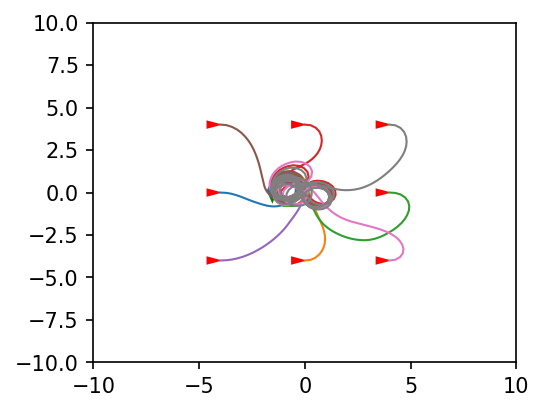

In [31]:

controller_path = "examples/tripods/lc/ackermann_l_deterministic.pt"
controller_path = prx.lib_path + controller_path
controller = torch.load(controller_path)
controller.eval()
torch.manual_seed(params["random_seed"].as_int())
radius = 0.1

ctrl_input = torch.zeros(1, 6)

def compute_trajectory_lc(start_state_v, end_state_v):
    solution_traj = prx.trajectory(ss);
    ss.copy_from_vector(start_state_v)
    ss.copy_point_from_vector(goal_state, end_state_v)
    checker.reset()
    solution_traj.copy_onto_back(ss);

    while True:
        
        ctrl_input[0, 0] = solution_traj.back()[0]
        ctrl_input[0, 1] = solution_traj.back()[1]
        ctrl_input[0, 2] = solution_traj.back()[2]
        ctrl_input[0, 3] = goal_state[0]
        ctrl_input[0, 4] = goal_state[1]
        ctrl_input[0, 5] = goal_state[2]
        
        with torch.no_grad():
            ctrl_output = controller(ctrl_input)[0].cpu()
        
        ctrl = [-np.pi/3 + ((ctrl_output[0].item() + 1)*np.pi/3),
                    (ctrl_output[1].item() + 1)*15]
        cs.copy_from_vector(ctrl)
        cs.enforce_bounds()
        plant.propagate(0.01)

        solution_traj.copy_onto_back(ss);

        if checker.check() or prx.space_t.euclidean_2d(solution_traj.back(), goal_state, 0, 3) <= 0.1:
            break
    return solution_traj


def plot_trajs_lc(trajs):
    fig = plt.figure(figsize=(8, 3), dpi=150, frameon=False)
    plot_limits = np.column_stack(([-10, -10], [10, 10]))

    ax = plt.subplot(121)
    
    result = ss.make_point()
    
    disc = 10
    for traj in trajs:
        xs = []
        ys = []
        for t_i in range(len(traj)-1):
            for i in range(disc):
            
                ss.interpolate(traj[t_i], traj[t_i + 1], i/disc, result)
                xs.append(result[0])
                ys.append(result[1])

        ax.plot(xs, ys, '-', linewidth=1)
        plt.arrow(xs[0], ys[0], 0.1*np.cos(traj[0][2]), 0.1*np.sin(traj[0][2]), shape='full', lw=0, length_includes_head=True, head_width=.5, color="red")
        plt.arrow(xs[-2], ys[-2], 0.1*np.cos(traj[len(traj)-1][2]), 0.1*np.sin(traj[len(traj)-1][2]), shape='full', lw=0, length_includes_head=False, head_width=.5, color="green")
    ax.set_xlim(plot_limits[0])
    ax.set_ylim(plot_limits[1])





trajs_lc = compute_trajectories(s_points, [0,0,np.pi/2], compute_trajectory_lc)




plot_trajs_lc(trajs_lc)



[[-4, 0, 0], [0, -4, 0], [4, 0, 0], [0, 4, 0], [-4, -4, 0], [-4, 4, 0], [4, -4, 0], [4, 4, 0]]


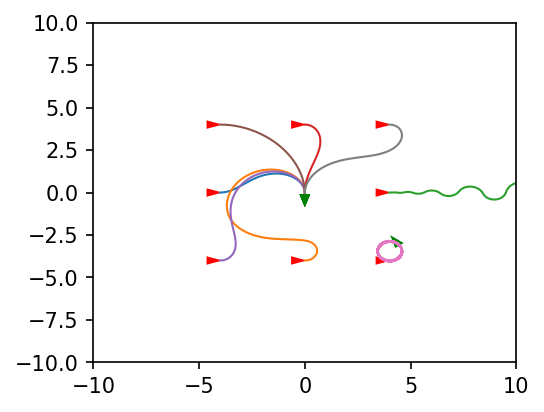

In [6]:
# r = R.from_euler('z', prx.PRX_PI, degrees=False)
# s_points_2 = list(map(r.apply, s_points))
s_points_2 = s_points
print(list(s_points_2))
trajs_2 = compute_trajectories(s_points_2, [0,0,-prx.PRX_PI/2.])

plot_trajs(trajs_2)

[[-4, 0, 0], [0, -4, 0], [4, 0, 0], [0, 4, 0], [-4, -4, 0], [-4, 4, 0], [4, -4, 0], [4, 4, 0]]


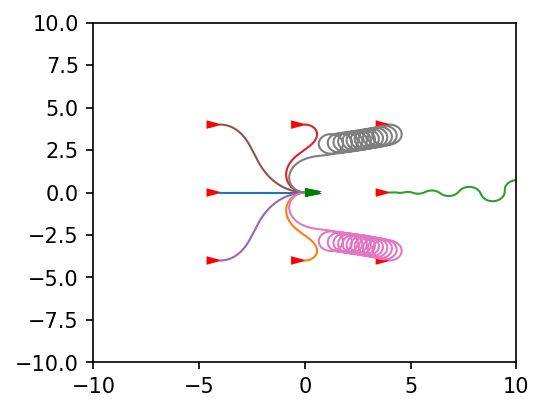

In [7]:
r = R.from_euler('z', np.pi/2, degrees=False)
s_points_3 = s_points
print(list(s_points_3))
trajs_3 = compute_trajectories(s_points_3, [0,0,0])

plot_trajs(trajs_3)

[array([-8.8817842e-16, -4.0000000e+00,  0.0000000e+00]), array([ 4.0000000e+00, -8.8817842e-16,  0.0000000e+00]), array([8.8817842e-16, 4.0000000e+00, 0.0000000e+00]), array([-4.0000000e+00,  8.8817842e-16,  0.0000000e+00]), array([ 4., -4.,  0.]), array([-4., -4.,  0.]), array([4., 4., 0.]), array([-4.,  4.,  0.])]


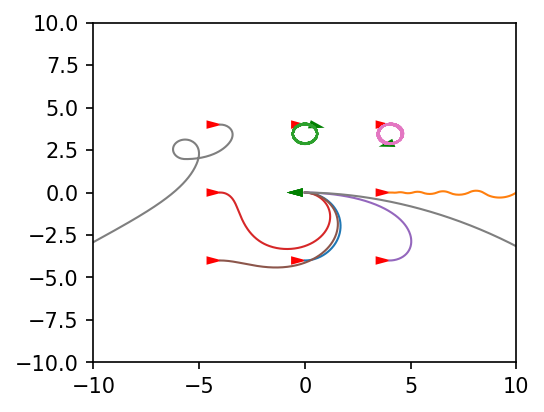

In [10]:
r = R.from_euler('z', np.pi/2, degrees=False)
s_points_3 = list(map(r.apply, s_points))
# s_points_3 = s_points
print(list(s_points_3))
trajs_3 = compute_trajectories(s_points_3, [0,0,prx.PRX_PI])

plot_trajs(trajs_3)

[array([-8.8817842e-16, -4.0000000e+00,  0.0000000e+00]), array([ 4.0000000e+00, -8.8817842e-16,  0.0000000e+00]), array([8.8817842e-16, 4.0000000e+00, 0.0000000e+00]), array([-4.0000000e+00,  8.8817842e-16,  0.0000000e+00]), array([ 4., -4.,  0.]), array([-4., -4.,  0.]), array([4., 4., 0.]), array([-4.,  4.,  0.])]


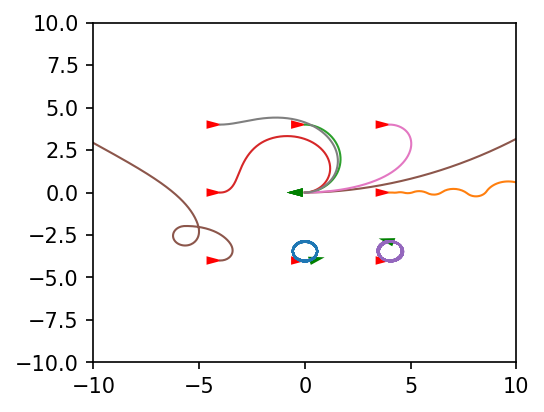

In [11]:
r = R.from_euler('z', prx.PRX_PI/2., degrees=False)
s_points_3 = list(map(r.apply, s_points))
# s_points_3 = s_points
print(list(s_points_3))
trajs_3 = compute_trajectories(s_points_3, [0,0,-prx.PRX_PI])

plot_trajs(trajs_3)